No GPU available, using CPU.
Found 1548 files belonging to 3 classes.
Found 388 files belonging to 3 classes.
Found 216 files belonging to 3 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 39s 1us/step
Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.4930 - loss: 3.2877 - val_accuracy: 0.7371 - val_loss: 0.8123
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.7172 - loss: 0.9348 - val_accuracy: 0.9124 - val_loss: 0.2476
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.8585 - loss: 0.3986 - val_accuracy: 0.9046 - val_loss: 0.2653
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9017 - loss: 0.2785 - val_accuracy: 0.9201 - val_loss: 0.2412
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9155 - loss: 0.2550 - val_accuracy: 0.9485 - val_loss: 0.1676
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9359 - loss: 0.1901 - val_accuracy: 0.9433 - val_loss: 0.1565
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 

Training time: 1747.40 seconds
Model saved to densenet_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 444ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.97      0.98       100
     Class 1       0.96      0.99      0.98       100
     Class 2       1.00      0.94      0.97        16

    accuracy                           0.98       216
   macro avg       0.98      0.97      0.97       216
weighted avg       0.98      0.98      0.98       216

Accuracy: 97.69%


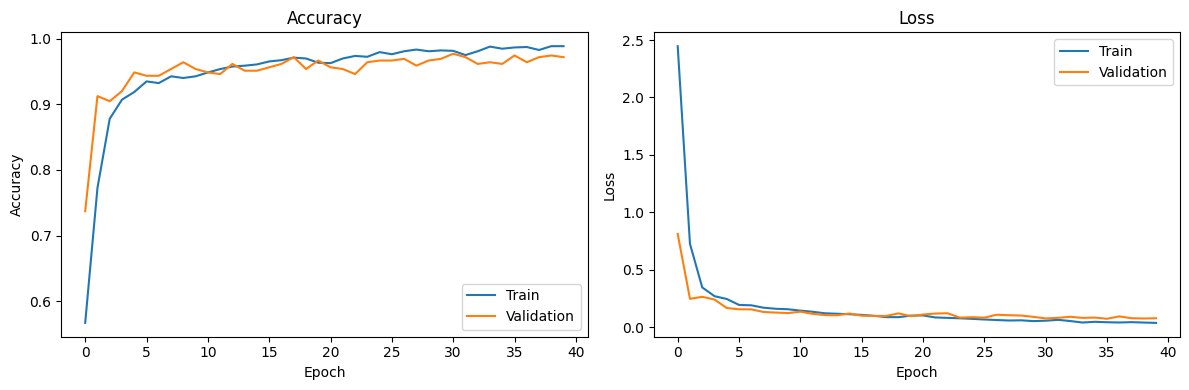

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.applications import DenseNet121
import time
import pickle

# Constants
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 100
EPOCHS = 40  # Reduce the number of epochs for quicker experimentation
dataset_dir = "./dataset"
testing_dir = "./testing"
validation_dir = "./validation"
training_dir = "./training"

# Check if GPU is available and set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f'{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs')
    except RuntimeError as e:
        print(e)
else:
    print('No GPU available, using CPU.')

# Function to configure datasets for performance
def configure_for_performance(ds):
    ds = ds.cache()
    ds = ds.shuffle(buffer_size=1000)
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

# Load the augmented training dataset
augmented_dataset = tf.keras.utils.image_dataset_from_directory(
    training_dir,
    image_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=BATCH_SIZE,
    seed=123,
    validation_split=None  # Remove validation_split
)
augmented_dataset = configure_for_performance(augmented_dataset)

# Load the validation dataset
validation_fold_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=BATCH_SIZE
)
validation_fold_ds = configure_for_performance(validation_fold_ds)

# Load the testing dataset
test_fold_ds = tf.keras.utils.image_dataset_from_directory(
    testing_dir,
    image_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=BATCH_SIZE
)
test_fold_ds = configure_for_performance(test_fold_ds)

# Function to create a DenseNet model
def create_densenet_model(input_shape, num_classes):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the base model
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Function to calculate and print metrics
def calculate_metrics(model, test_dataset, num_classes):
    true_labels = []
    predicted_labels = []

    for images, labels in test_dataset:
        true_labels.extend(labels.numpy())
        predictions = model.predict(images)
        predicted_labels.extend(np.argmax(predictions, axis=1))

    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Print classification report
    print("Classification Report:")
    print(classification_report(true_labels, predicted_labels, target_names=[f"Class {i}" for i in range(num_classes)]))

    # Print accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Accuracy: {accuracy * 100:.2f}%")

# Create a DenseNet model
input_shape = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
densenet_model = create_densenet_model(input_shape, num_classes=3)

densenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model and calculate training time
start_time = time.time()

history = densenet_model.fit(
    augmented_dataset,
    epochs=EPOCHS,
    validation_data=validation_fold_ds,
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Save the history
history_path = 'training_history.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

# Optionally, you can save the entire model after training
model_path = "densenet_model.h5"
densenet_model.save(model_path)
print(f'Model saved to {model_path}')

# Calculate and print metrics on the testing dataset
calculate_metrics(densenet_model, test_fold_ds, num_classes=3)

# Plot Accuracy and Loss Graphs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
